In [6]:
import jax
from jax import jit
import jax.numpy as jnp
from functools import partial
import immrax as irx
from immutabledict import immutabledict
from two_tank_system import TwoTanks
import os, sys
sys.path.append( '..')
from faulty_car.interval_functions import overlap_size_lax, overlap_size, propagate_interval
# Define initial state bounds (intervals) using icentpert
from typing import Union

In [99]:
base_two_tanks = TwoTanks()
two_tank_embsys = irx.natemb(base_two_tanks)
initial_state_bounds = irx.icentpert(jnp.array([0.3, 0.05]), jnp.array([.0, .0])) #initial H1, H2. No uncertainty.
nominal_w_bounds = irx.interval(jnp.array([4.25e-4, 1.75e-4]), jnp.array([4.75e-4, 2.25e-4])) #bounds for qpbar, c2.
nominal_c_bounds = irx.interval(jnp.array([0.0, 5.75e-4]), jnp.array([0.0, 6.25e-4])) #bounds for cl, c12 under nominal system (t<150).
narrow_nominal_c_bounds = irx.interval(jnp.array([0.0, 6e-4]), jnp.array([0.0, 6e-4])) #bounds for cl, c12 under nominal system (t<150) with narrower bounds.
blocked_c_bounds = irx.interval(jnp.array([0.0, 0.]), jnp.array([0.0, 0.])) #bounds for cl, c12 under blocked system (Case 1, t>150).
leaky_c_bounds = irx.interval(jnp.array([2.6e-4, 5.75e-4]), jnp.array([2.6e-4, 6.25e-4])) #bounds for cl, c12 under leaky system (Case 2, t>150).
candidate_1_c_ivl = irx.interval(jnp.array([0.0, 0.0]), jnp.array([0.0, 5e-4])) #bounds for cl, c12 under candidate model #1.
candidate_2_c_ivl = irx.interval(jnp.array([2.35e-4, 5.75e-4]), jnp.array([2.85e-4, 6.25e-4])) #bounds for cl, c12 under candidate model #2.
measurement_noise_bounds = irx.icentpert(jnp.array([0.0, 0.0]), jnp.array([0.006, 0.006])) #bounds for measurement noise (H1, H2).

In [100]:
@jit
def propagate_interval_two_tanks(
    state_bounds: irx.Interval,
    w_bounds: irx.Interval,
    c_bounds: irx.Interval,
    t: float
) -> irx.Interval:
    """Propagate the interval for the two-tank system."""
    two_tank_embsys = irx.natemb(base_two_tanks)
    # Propagate the interval using the two-tank system dynamics
    def w_map_infunc(t, x):
        return w_bounds
    def c_map_infunc(t, x):
        return c_bounds
    x_traj = two_tank_embsys.compute_trajectory(0.0, t, irx.i2ut(state_bounds), (w_map_infunc, c_map_infunc))
    return x_traj

In [101]:
two_tank_embsys = irx.natemb(base_two_tanks)

def propagate_interval_two_tanks_euler(
    state_bounds: irx.Interval,
    w_bounds: irx.Interval,
    c_bounds: irx.Interval,
    t: float
) -> irx.Interval:
    """Propagate the interval for the two-tank system."""
    # Propagate the interval using the two-tank system dynamics
    x_next = two_tank_embsys.f(0.0, irx.i2ut(state_bounds), w_bounds, c_bounds) * t + irx.i2ut(state_bounds)
    return irx.ut2i(x_next)

In [102]:
two_tank_embsys = irx.natemb(base_two_tanks)
# Propagate the interval using the two-tank system dynamics
def w_map_infunc(t, x):
    return nominal_w_bounds
def c_map_infunc(t, x):
    return nominal_c_bounds
x_traj = two_tank_embsys.compute_trajectory(0.0, 150.0, irx.i2ut(initial_state_bounds), (w_map_infunc, c_map_infunc), solver='euler', dt=1.0)

Propagation of Nominal System for the first 150s

Evolution of ACTUAL nominal system. This picks a value from nominal c bounds at each dt=1s.

In [104]:
key = jax.random.PRNGKey(42)
def select_random_value_from_interval(ivl: irx.Interval) -> Union[float, jnp.ndarray]:
    """Select a random value from the interval."""
    return jax.random.uniform(key, shape=ivl.lower.shape, minval=ivl.lower, maxval=ivl.upper)

In [105]:
def select_w_and_c_values_from_bounds(
    w_bounds: irx.Interval,
    c_bounds: irx.Interval,
) -> Union[irx.Interval, irx.Interval]:
    """Randomly pick a value from the bounds for w and c."""
    w_value = select_random_value_from_interval(w_bounds)
    c_value = select_random_value_from_interval(c_bounds)
    return w_value, c_value


In [135]:
import copy
true_state = copy.deepcopy(initial_state_bounds)
measurement = true_state
list_of_states = [true_state]
list_of_measurements = [true_state]
list_of_c1_states = [true_state]
list_of_c2_states = [true_state]
for t in range(0, 150):
    w_value, c_value = select_w_and_c_values_from_bounds(nominal_w_bounds, nominal_c_bounds)
    w_ivl = irx.icentpert(w_value, jnp.zeros_like(w_value))  # Create trivial interval from selected value
    c_ivl = irx.icentpert(c_value, jnp.zeros_like(c_value))  # Create trivial interval from selected value
    candidate_1_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_1_c_ivl,
        1.0
    )
    list_of_c1_states.append(candidate_1_prediction)
    candidate_2_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_2_c_ivl,
        1.0
    )
    list_of_c2_states.append(candidate_2_prediction)
    true_state = propagate_interval_two_tanks_euler(
        true_state,
        w_ivl,
        c_ivl,
        1.0
    )
    list_of_states.append(true_state)
    measurement_noise = select_random_value_from_interval(measurement_noise_bounds)
    measurement = true_state + measurement_noise  # Add measurement noise to the true state
    list_of_measurements.append(measurement)
    
# A leak happens at t=150, so we switch to leaky bounds.
for t in range(150, 200):
    w_value, c_value = select_w_and_c_values_from_bounds(nominal_w_bounds, leaky_c_bounds)
    w_ivl = irx.icentpert(w_value, jnp.zeros_like(w_value))  # Create trivial interval from selected value
    c_ivl = irx.icentpert(c_value, jnp.zeros_like(c_value))  # Create trivial interval from selected value
    candidate_1_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_1_c_ivl,
        1.0
    )
    list_of_c1_states.append(candidate_1_prediction)
    candidate_2_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_2_c_ivl,
        1.0
    )
    list_of_c2_states.append(candidate_2_prediction)
    true_state = propagate_interval_two_tanks_euler(
        true_state,
        w_ivl,
        c_ivl,
        1.0
    )
    list_of_states.append(true_state)
    measurement_noise = select_random_value_from_interval(measurement_noise_bounds)
    measurement = true_state + measurement_noise  # Add measurement noise to the true state
    list_of_measurements.append(measurement)

In [136]:
ts = []
true_h0s = []
true_h1s = []
meas_h0s = []
meas_h1s = []
c1_h0_lowers = []
c1_h0_uppers = []
c1_h1_lowers = []
c1_h1_uppers = []
c2_h0_lowers = []
c2_h0_uppers = []
c2_h1_lowers = []
c2_h1_uppers = []
for t in range(0, len(list_of_states)):
    true_h0 = list_of_states[t].lower[0]
    true_h1 = list_of_states[t].lower[1]
    measurement_h0 = list_of_measurements[t].lower[0]
    measurement_h1 = list_of_measurements[t].lower[1]
    c1_h0_lower = list_of_c1_states[t].lower[0] + measurement_noise_bounds.lower[0]
    c1_h0_upper = list_of_c1_states[t].upper[0] + measurement_noise_bounds.upper[0]
    c1_h1_lower = list_of_c1_states[t].lower[1] + measurement_noise_bounds.lower[1]
    c1_h1_upper = list_of_c1_states[t].upper[1] + measurement_noise_bounds.upper[1]
    c2_h0_lower = list_of_c2_states[t].lower[0] + measurement_noise_bounds.lower[0]
    c2_h0_upper = list_of_c2_states[t].upper[0] + measurement_noise_bounds.upper[0]
    c2_h1_lower = list_of_c2_states[t].lower[1] + measurement_noise_bounds.lower[1]
    c2_h1_upper = list_of_c2_states[t].upper[1] + measurement_noise_bounds.upper[1]
    ts.append(t)
    true_h0s.append(true_h0)
    true_h1s.append(true_h1)
    meas_h0s.append(measurement_h0)
    meas_h1s.append(measurement_h1)
    c1_h0_lowers.append(c1_h0_lower)
    c1_h0_uppers.append(c1_h0_upper)
    c1_h1_lowers.append(c1_h1_lower)        
    c1_h1_uppers.append(c1_h1_upper)
    c2_h0_lowers.append(c2_h0_lower)
    c2_h0_uppers.append(c2_h0_upper)
    c2_h1_lowers.append(c2_h1_lower)        
    c2_h1_uppers.append(c2_h1_upper)


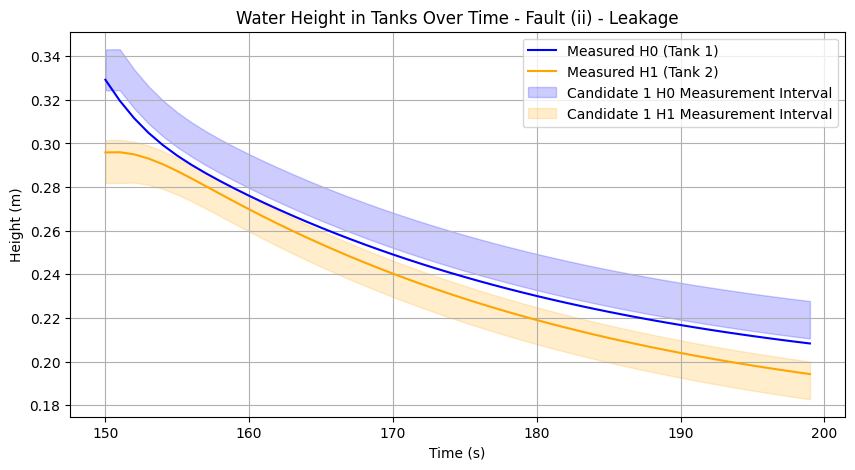

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
start_time = 150
end_time = 200
CANDIDATE = 2
plt.plot(ts[start_time:end_time], meas_h0s[start_time:end_time], label='Measured H0 (Tank 1)', color='blue')
plt.plot(ts[start_time:end_time], meas_h1s[start_time:end_time], label='Measured H1 (Tank 2)', color='orange')
if CANDIDATE == 1:
    plt.fill_between(ts[start_time:end_time], c1_h0_lowers[start_time:end_time], c1_h0_uppers[start_time:end_time], color='blue', alpha=0.2, label='Candidate 1 H0 Measurement Interval')
    plt.fill_between(ts[start_time:end_time], c1_h1_lowers[start_time:end_time], c1_h1_uppers[start_time:end_time], color='orange', alpha=0.2, label='Candidate 1 H1 Measurement Interval')
if CANDIDATE == 2:
    plt.fill_between(ts[start_time:end_time], c2_h0_lowers[start_time:end_time], c2_h0_uppers[start_time:end_time], color='blue', alpha=0.2, label='Candidate 2 H0 Measurement Interval')
    plt.fill_between(ts[start_time:end_time], c2_h1_lowers[start_time:end_time], c2_h1_uppers[start_time:end_time], color='orange', alpha=0.2, label='Candidate 2 H1 Measurement Interval')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Water Height in Tanks Over Time - Fault (ii) - Leakage')
plt.legend()
plt.grid()
plt.show()

This is plot of actual system before t=150s. Now, we plot candidates' FRS estimates given measured state.

Next, we do Fault (i), blocked pipe.

In [128]:
import copy
true_state = copy.deepcopy(initial_state_bounds)
measurement = true_state
list_of_states = [true_state]
list_of_measurements = [true_state]
list_of_c1_states = [true_state]
list_of_c2_states = [true_state]
for t in range(0, 150):
    w_value, c_value = select_w_and_c_values_from_bounds(nominal_w_bounds, nominal_c_bounds)
    w_ivl = irx.icentpert(w_value, jnp.zeros_like(w_value))  # Create trivial interval from selected value
    c_ivl = irx.icentpert(c_value, jnp.zeros_like(c_value))  # Create trivial interval from selected value
    candidate_1_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_1_c_ivl,
        1.0
    )
    list_of_c1_states.append(candidate_1_prediction)
    candidate_2_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_2_c_ivl,
        1.0
    )
    list_of_c2_states.append(candidate_2_prediction)
    true_state = propagate_interval_two_tanks_euler(
        true_state,
        w_ivl,
        c_ivl,
        1.0
    )
    list_of_states.append(true_state)
    measurement_noise = select_random_value_from_interval(measurement_noise_bounds)
    measurement = true_state + measurement_noise  # Add measurement noise to the true state
    list_of_measurements.append(measurement)
    
# A pipe is blocked at t=150, so we switch to blocked bounds.
for t in range(150, 200):
    w_value, c_value = select_w_and_c_values_from_bounds(nominal_w_bounds, blocked_c_bounds)
    w_ivl = irx.icentpert(w_value, jnp.zeros_like(w_value))  # Create trivial interval from selected value
    c_ivl = irx.icentpert(c_value, jnp.zeros_like(c_value))  # Create trivial interval from selected value
    candidate_1_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_1_c_ivl,
        1.0
    )
    list_of_c1_states.append(candidate_1_prediction)
    candidate_2_prediction = propagate_interval_two_tanks_euler(
        measurement,
        nominal_w_bounds,
        candidate_2_c_ivl,
        1.0
    )
    list_of_c2_states.append(candidate_2_prediction)
    true_state = propagate_interval_two_tanks_euler(
        true_state,
        w_ivl,
        c_ivl,
        1.0
    )
    list_of_states.append(true_state)
    measurement_noise = select_random_value_from_interval(measurement_noise_bounds)
    measurement = true_state + measurement_noise  # Add measurement noise to the true state
    list_of_measurements.append(measurement)

In [129]:
ts = []
true_h0s = []
true_h1s = []
meas_h0s = []
meas_h1s = []
c1_h0_lowers = []
c1_h0_uppers = []
c1_h1_lowers = []
c1_h1_uppers = []
c2_h0_lowers = []
c2_h0_uppers = []
c2_h1_lowers = []
c2_h1_uppers = []
for t in range(0, len(list_of_states)):
    true_h0 = list_of_states[t].lower[0]
    true_h1 = list_of_states[t].lower[1]
    measurement_h0 = list_of_measurements[t].lower[0]
    measurement_h1 = list_of_measurements[t].lower[1]
    c1_h0_lower = list_of_c1_states[t].lower[0] + measurement_noise_bounds.lower[0]
    c1_h0_upper = list_of_c1_states[t].upper[0] + measurement_noise_bounds.upper[0]
    c1_h1_lower = list_of_c1_states[t].lower[1] + measurement_noise_bounds.lower[1]
    c1_h1_upper = list_of_c1_states[t].upper[1] + measurement_noise_bounds.upper[1]
    c2_h0_lower = list_of_c2_states[t].lower[0] + measurement_noise_bounds.lower[0]
    c2_h0_upper = list_of_c2_states[t].upper[0] + measurement_noise_bounds.upper[0]
    c2_h1_lower = list_of_c2_states[t].lower[1] + measurement_noise_bounds.lower[1]
    c2_h1_upper = list_of_c2_states[t].upper[1] + measurement_noise_bounds.upper[1]
    ts.append(t)
    true_h0s.append(true_h0)
    true_h1s.append(true_h1)
    meas_h0s.append(measurement_h0)
    meas_h1s.append(measurement_h1)
    c1_h0_lowers.append(c1_h0_lower)
    c1_h0_uppers.append(c1_h0_upper)
    c1_h1_lowers.append(c1_h1_lower)        
    c1_h1_uppers.append(c1_h1_upper)
    c2_h0_lowers.append(c2_h0_lower)
    c2_h0_uppers.append(c2_h0_upper)
    c2_h1_lowers.append(c2_h1_lower)        
    c2_h1_uppers.append(c2_h1_upper)


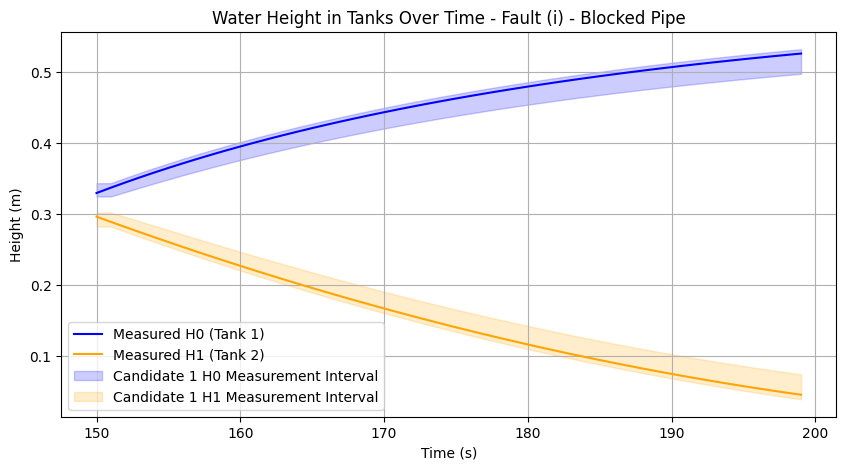

In [131]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
start_time = 150
end_time = 200
CANDIDATE = 1
plt.plot(ts[start_time:end_time], meas_h0s[start_time:end_time], label='Measured H0 (Tank 1)', color='blue')
plt.plot(ts[start_time:end_time], meas_h1s[start_time:end_time], label='Measured H1 (Tank 2)', color='orange')
if CANDIDATE == 1:
    plt.fill_between(ts[start_time:end_time], c1_h0_lowers[start_time:end_time], c1_h0_uppers[start_time:end_time], color='blue', alpha=0.2, label='Candidate 1 H0 Measurement Interval')
    plt.fill_between(ts[start_time:end_time], c1_h1_lowers[start_time:end_time], c1_h1_uppers[start_time:end_time], color='orange', alpha=0.2, label='Candidate 1 H1 Measurement Interval')
if CANDIDATE == 2:
    plt.fill_between(ts[start_time:end_time], c2_h0_lowers[start_time:end_time], c2_h0_uppers[start_time:end_time], color='blue', alpha=0.2, label='Candidate 2 H0 Measurement Interval')
    plt.fill_between(ts[start_time:end_time], c2_h1_lowers[start_time:end_time], c2_h1_uppers[start_time:end_time], color='orange', alpha=0.2, label='Candidate 2 H1 Measurement Interval')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Water Height in Tanks Over Time - Fault (i) - Blocked Pipe')
plt.legend()
plt.grid()
plt.show()

In [61]:
%timeit propagate_interval_two_tanks_euler(true_state,w_ivl,c_ivl,1.0)

2.96 ms ± 50.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [31]:
state_traj = propagate_interval_two_tanks_euler(state_bounds=initial_state_bounds,
                            w_bounds=nominal_w_bounds,
                            c_bounds=nominal_c_bounds,
                            t=150.0)  # Propagate to t=150 seconds

In [32]:
print("State trajectory at t=150 seconds:", state_traj)

State trajectory at t=150 seconds: [[(-1.53136706, -1.14521813)]
 [( 2.36027741,  2.71268344)]]


In [ ]:
def monte_carlo_simulation(
    system: irx.System,
    initial_state_bounds: irx.Interval,
    nominal_w_bounds: irx.Interval,
    nominal_c_bounds: irx.Interval,
    blocked_c_bounds: irx.Interval,
    leaky_c_bounds: irx.Interval,
    candidate_1_c_ivl: irx.Interval,
    candidate_2_c_ivl: irx.Interval,
    num_samples: int = 1000
) -> Union[immutabledict, immutabledict]:
    """
    Run Monte Carlo simulation for the Two Tanks system with given parameters.
    
    Args:
        system (irx.System): The Two Tanks system to simulate.
        initial_state_bounds (irx.Interval): Initial state bounds.
        nominal_w_bounds (irx.Interval): Nominal bounds for w.
        nominal_c_bounds (irx.Interval): Nominal bounds for c.
        blocked_c_bounds (irx.Interval): Bounds for blocked c.
        leaky_c_bounds (irx.Interval): Bounds for leaky c.
        candidate_1_c_ivl (irx.Interval): Candidate model #1 bounds for c.
        candidate_2_c_ivl (irx.Interval): Candidate model #2 bounds for c.
        num_samples (int): Number of samples to generate.

    Returns:
        immutabledict: Results of the simulation.
    """
    
    
    
    return results